# M5 Practice: Data Visualization with  Data

This practice notebook provides additional preparation for Assignment 5. 

#### 1. Setup
* 1.1 Import the Path, Pandas, Seaborn, and Calendar packages into your notebook
* 1_2 Set path objects for your project folder, the raw data folder, and the `Processed_Key` folder

In [2]:
# 1_1 Packages
from pathlib import Path
import pandas as pd
import seaborn as sns
import calendar

In [3]:
# 1.2 Paths 
project_fldr = Path.cwd().parent
raw_fldr = project_fldr / 'data' / 'raw'
processed_fldr = project_fldr / 'data' / 'Processed_Key'

In [4]:
# 1.3 Dictionary to map month to season
month_to_season = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall', 10: 'Fall', 11: 'Fall'
}

#### 2. Ingest Data & Wrangle
* Import the processed USGS Flow dataset (`SGS_Site02085000_Flow_Processed.csv`) - located in the `Processed_Key` folder. 
    - Set the datetime column to be a datetime object
    - Create `month`, `year`, and `season` columns. (Use the `month_to_season` dictionary for the `season` column.)
* Create a `month_abb` column of abbreviated month names, set as a categorical field with levels for each month. 
* Add a column indicating whether the record occurred before, during, or after Falls Lake dam construction. (Construction started in 1979 and completed in 1981 - [Source](https://www.saw.usace.army.mil/portals/59/docs/recreation/fallslake/images/falls%20lake%20master%20plan%20june%2021%202013%20final.pdf))

In [5]:
#Import USGS flow data, deriving month, year, and season columns from datetime
USGS_flow = (
    pd.read_csv(
        processed_fldr/'USGS_Site02085000_Flow_Processed.csv',
        usecols = [
            'datetime', 
            'discharge_max','discharge_min','discharge_mean',
            'gage_height_max', 'gage_height_min', 'gage_height_mean',
            ],
        parse_dates=['datetime']
    )
    .assign(
        month = lambda df: df['datetime'].dt.month,
        year = lambda df: df['datetime'].dt.year,
        season = lambda df: df['month'].map(month_to_season)
    )
)

In [6]:
#Create a month category, with levels for each month
USGS_flow['month_abb'] = pd.Categorical(
    values=USGS_flow['datetime'].dt.month_name().str[:3],
    categories=calendar.month_abbr[1:]
)

In [8]:
def dam_status(year):
    if year < 1979:
        return 'before'
    elif year <= 1981:
        return 'during'
    else:
        return 'after'

USGS_flow['dam'] = USGS_flow['year'].map(dam_status)

In [10]:
#Examine the dataframe
USGS_flow.head()

,datetime,discharge_max,discharge_min,discharge_mean,gage_height_max,gage_height_min,gage_height_mean,month,year,season,month_abb,dam
0,1928-01-01,NaN,NaN,74.0,NaN,NaN,NaN,1,1928,Winter,Jan,before
1,1928-01-02,NaN,NaN,61.0,NaN,NaN,NaN,1,1928,Winter,Jan,before
2,1928-01-03,NaN,NaN,56.0,NaN,NaN,NaN,1,1928,Winter,Jan,before
3,1928-01-04,NaN,NaN,54.0,NaN,NaN,NaN,1,1928,Winter,Jan,before
4,1928-01-05,NaN,NaN,48.0,NaN,NaN,NaN,1,1928,Winter,Jan,before


#### 3. Craft your Seaborn Theme
* Set your theme to be based on Seaborn's `whitegrid` template.
* As we are working in notebook format, set the context to `notebook`.
* Explore [Seaborn's palettes](https://seaborn.pydata.org/tutorial/color_palettes.html#qualitative-color-palettes) and set your palette to one of the qualitative palettes. 
* Set its palette to be colorblind friendly and set the font scale to 0.8 (Hint: See <https://seaborn.pydata.org/generated/seaborn.set_theme.html>)
* Set two of the theme's runtime configuration (`rc`) options. ([Hint](https://seaborn.pydata.org/generated/seaborn.axes_style.html))

In [11]:
# Set the default theme attributes
sns.set_theme(style='whitegrid',
              context='notebook',
              palette='colorblind',
              font_scale=0.8,
              rc={
                  'xtick.bottom':True,
                  'ytick.left':True
              })

#### 📊Task 1: Plot discharge over time
* Create a line plot showing values of mean discharge over the span of the data we have. 
* Color the line by dam construction status. 
* Give the plot a title. 
* Remove the x-axis label (set it to an empty string: `""`)
* Set the y-axis label to "Discharge cfs"
* Title the legend "Construciton Status"
* Place the legend in the upper left corner, enclosed in a box. 

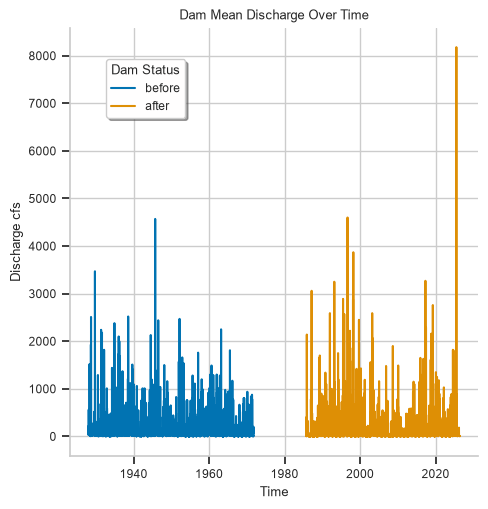

In [12]:
# Create a line plot of discharge over time
g = sns.relplot(
    data=USGS_flow,
    x='datetime',
    y= 'discharge_mean',
    kind='line',
    hue='dam'
).set(
    title='Dam Mean Discharge Over Time',
    xlabel='Time',
    ylabel='Discharge cfs'
);
sns.move_legend(
    g, 
    loc='upper left', #Switch to "upper left"
    title='Dam Status',
    facecolor="#FFFEFE",
    shadow=True,
    bbox_to_anchor=(0.2,0.92),
    #title_fontsize=12,
    #fontsize=10,
    #ncols=1,
    frameon=True
)

#### ✅ Question
**Would you say this is a useful plot? Why or why not? What might improve it?**
> **Answer**:  
>  

---
#### 📊Task 2: Plot the number of records with valid minimum discharge values by year
* Determine which plot function to use: `relplot()`, `displot()`, or `catplot()`
* Determine which subplot function to use (e.g. "scatterplot" for relplot, "swarmplot" for catplot).
* Craft your plot to use the appropriate dataset and which variables to assign to which axes.
* Adjust the style of your plot to look tidy and professional:
    - Set the height and aspect of your plot to ensure it's clear and uses space accordingly.
    - Give your plot a title, and set axis labels appropriately. (Note: "Year' is an optional label when obvious.)

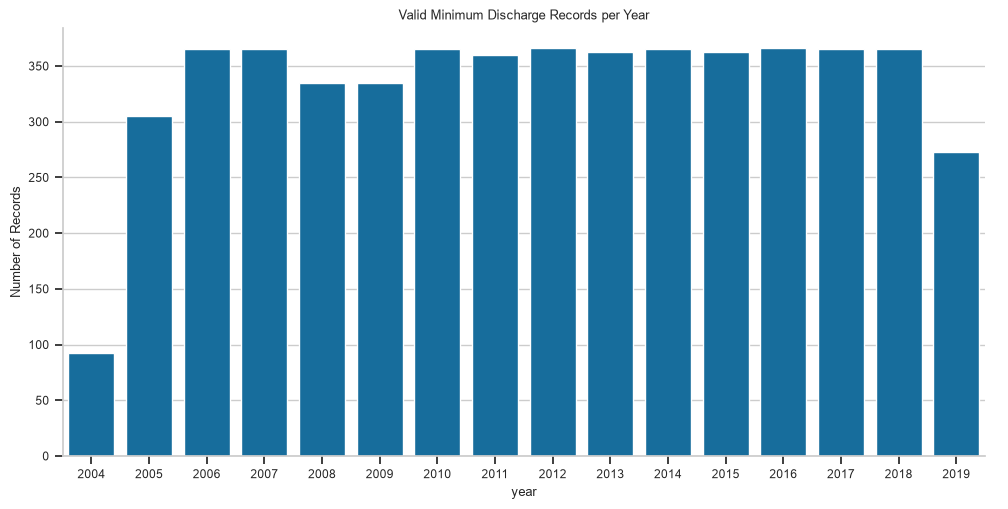

In [28]:
# Plot the number of records by year
USGS_flow_valid = USGS_flow.loc[USGS_flow['discharge_min'].notna()]
g = sns.catplot(
    data=USGS_flow_valid,
    kind='count',
    x='year',
    aspect=2
).set(
    title='Valid Minimum Discharge Records per Year',
    ylabel='Number of Records'
);

##### ✅Question:
**What does this plot reveal about when the USGS recorded minimum and maximum discharge?**
> **Answer**
>

---
#### 📊Task 3: Plot the distribution of mean discharge by month
We want to examine monthly trends in discharge: is more water flowing through the sites some months than others? Is there a trend across months? To explore this, construct a plot that displays the typical (mean or median) discharge in a given month as well as some indication of the range of values. As before, make this plot tidy and professional. 


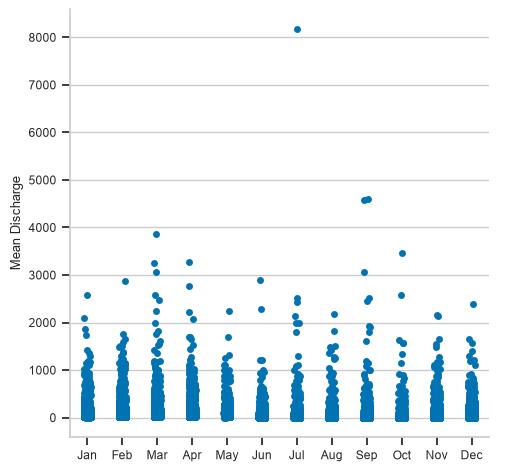

In [50]:
# Plot mean discharge by month
g = sns.catplot(
    data=USGS_flow,
    x='month_abb',
    y='discharge_mean'
).set(
    xlabel='',
    ylabel='Mean Discharge'
);

---
#### 📊Task 4: Alter the above plot to compare trends before and after dam construction
* Copy and paste your above code into the code cell below
* Color the monthly mean discharge values by the dam construction category.
* Change your plot type to `point`.

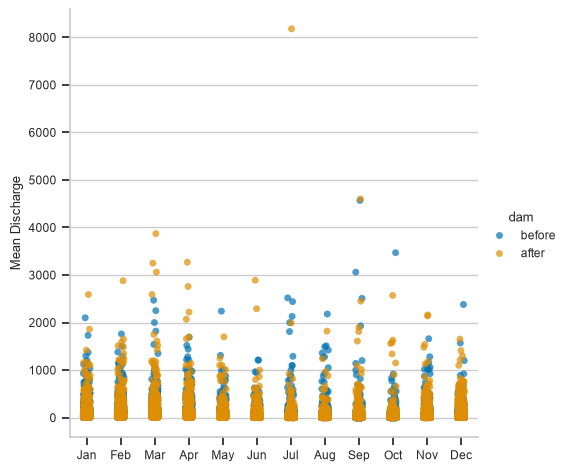

In [54]:
# Plot mean discharge by month, with separate plot features for records before and after dam construction

g = sns.catplot(
    data=USGS_flow,
    x='month_abb',
    y='discharge_mean',
    hue='dam',
    alpha=0.7
).set(
    xlabel='',
    ylabel='Mean Discharge'
);

##### ✅Question:
**Does this plot suggest any differences in monthly discharge patterns before/after the dam?**
> **Answer**
>

---
#### 📊Task 5: Split before/after dam construction as separate *facets*
* Show separate plots of monthly mean discharge
* Stack the plots vertically
* Assing the facetgrid object produced by your plotting to the variable `g`
* Append the code in the subsequent code cell to set titles and axes labels. (Note that facet plots produce a list of facetgrid objects that we can access individually).

In [ ]:
# Split the plot of monthly mean discharges into facets of before and after construction


In [ ]:
# Merge this code cell with your code cell above 
g.axes[0].set(
    title = 'Monthly discharge: Before Dam Construction',
    xlabel= '',
    ylabel= 'Discharge (cfs)'
    )

g.axes[1].set(
    title = 'Monthly discharge :After Dam Construction',
    xlabel= '',
    ylabel= 'Discharge (cfs)'
    )

# Show the plot
g;

##### ✅Question:
**Which of the last two plots shows the data more effectively?**
> **Answer**
>